In [1]:
# 1. Importando a biblioteca que lida com tabelas de dados (pandas)
import pandas as pd
from sklearn.datasets import load_breast_cancer

# 2. Carregando o dataset nativo de Câncer de Mama
datos = load_breast_cancer()

# 3. Transformando em uma tabela (DataFrame) visível
X = pd.DataFrame(datos.data, columns=datos.feature_names)
y = pd.Series(datos.target) # 0 = Benigno, 1 = Maligno (ou vice-versa dependendo do mapeamento)

# 4. Exibindo as primeiras 5 linhas da tabela
print("✅ Dados carregados com sucesso!")
print(f"Total de pacientes/amostras: {X.shape[0]}")
print(f"Total de características clínicas (colunas): {X.shape[1]}\n")

# Mostra as primeiras linhas da tabela na tela
X.head()

✅ Dados carregados com sucesso!
Total de pacientes/amostras: 569
Total de características clínicas (colunas): 30



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
# Passo 2: Verificar se há dados nulos (faltantes) ou duplicados
print("🔍 VERIFICANDO A QUALIDADE DOS DADOS...\n")

# Checa valores nulos em cada coluna
nulos_totais = X.isnull().sum().sum()
print(f"-> Total de valores nulos/faltantes na base: {nulos_totais}")

# Checa se existem linhas duplicadas
duplicados = X.duplicated().sum()
print(f"-> Total de linhas 100% duplicadas: {duplicados}")

# Mostra a distribuição dos diagnósticos (Target)
# 0 = Maligno, 1 = Benigno no scikit-learn
print("\n📊 DISTRIBUIÇÃO DAS CLASSES (DIAGNÓSTICO):")
print(y.value_counts().rename(index={0: "Maligno (0)", 1: "Benigno (1)"}))

🔍 VERIFICANDO A QUALIDADE DOS DADOS...

-> Total de valores nulos/faltantes na base: 0
-> Total de linhas 100% duplicadas: 0

📊 DISTRIBUIÇÃO DAS CLASSES (DIAGNÓSTICO):
Benigno (1)    357
Maligno (0)    212
Name: count, dtype: int64


In [3]:
# Passo 3: Divisão 80/20 Stratified + Normalização (StandardScaler)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separando 80% para treino e 20% para teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2. Criando e aplicando o Padronizador (StandardScaler)
scaler = StandardScaler()

# O fit_transform é feito APENAS no treino!
X_train_scaled = scaler.fit_transform(X_train)

# No teste usamos APENAS o transform (sem vazar dados do teste para o treino)
X_test_scaled = scaler.transform(X_test)

print("✅ Divisão e Normalização concluídas com sucesso!")
print(f"-> Quantidade de dados de TREINO (80%): {X_train.shape[0]} pacientes")
print(f"-> Quantidade de dados de TESTE (20%): {X_test.shape[0]} pacientes")

✅ Divisão e Normalização concluídas com sucesso!
-> Quantidade de dados de TREINO (80%): 455 pacientes
-> Quantidade de dados de TESTE (20%): 114 pacientes


In [4]:
# Passo 4: Treinamento dos 6 Modelos de Machine Learning

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import pandas as pd

# 1. Definindo o dicionário com os 6 modelos
modelos = {
    "Regressão Logística": LogisticRegression(random_state=42),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

# 2. Treinando e avaliando cada modelo nos dados de TESTE
resultados = []

for nome, modelo in modelos.items():
    # Treina o modelo usando os dados padronizados de treino
    modelo.fit(X_train_scaled, y_train)

    # Faz predições no conjunto de teste
    y_pred = modelo.predict(X_test_scaled)

    # Calcula as métricas principais
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Salva o resultado
    resultados.append({
        "Modelo": nome,
        "Acurácia": f"{acc:.4f}",
        "Sensibilidade (Recall)": f"{rec:.4f}",
        "Precisão": f"{prec:.4f}",
        "F1-Score": f"{f1:.4f}"
    })

# 3. Exibe os resultados em uma tabela bem formatada com Pandas
df_resultados = pd.DataFrame(resultados)
print("🏆 TABELA COMPARATIVA DOS MODELOS (DADOS DE TESTE):\n")
df_resultados

🏆 TABELA COMPARATIVA DOS MODELOS (DADOS DE TESTE):



,Modelo,Acurácia,Sensibilidade (Recall),Precisão,F1-Score
0,Regressão Logística,0.9825,0.9861,0.9861,0.9861
1,Árvore de Decisão,0.9123,0.9028,0.9559,0.9286
2,Random Forest,0.9561,0.9722,0.9589,0.9655
3,Gradient Boosting,0.9561,0.9861,0.9467,0.9660
4,SVM,0.9825,0.9861,0.9861,0.9861
5,KNN,0.9561,0.9722,0.9589,0.9655


🩺 ATRIBUTOS MAIS CRÍTICOS PARA O DIAGNÓSTICO MÉDICO (SHAP Summary Plot):



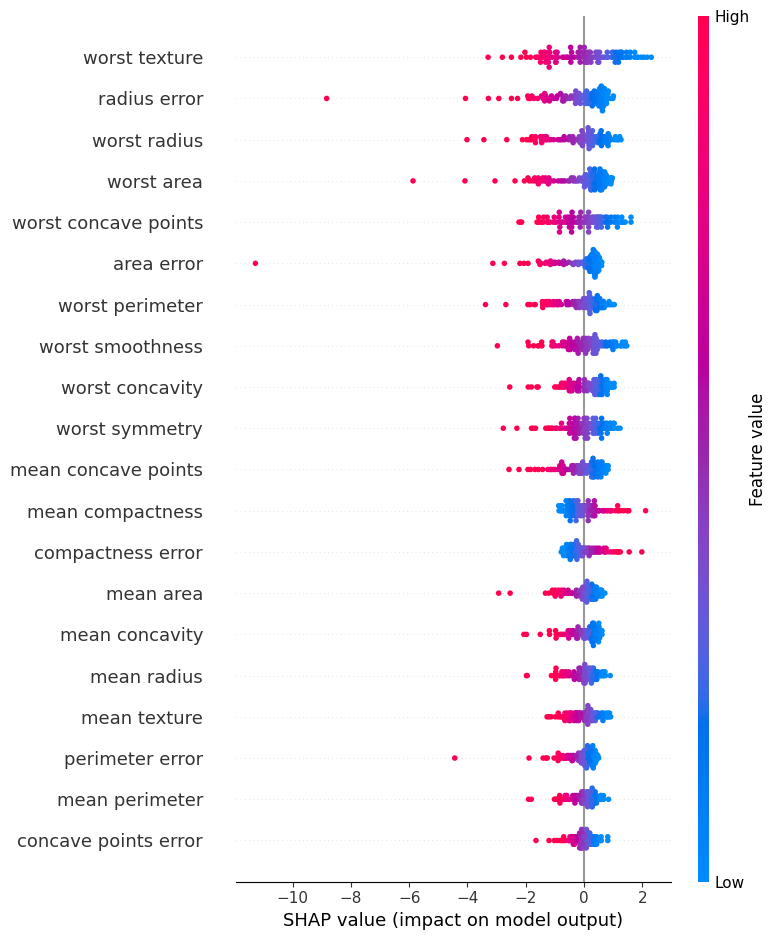

In [5]:
# Passo 5: Instalação e Análise de Explicabilidade com SHAP (Corrigido)
!pip install shap -q

import shap
import matplotlib.pyplot as plt

# 1. Selecionando o melhor modelo (Regressão Logística)
modelo_sucesso = modelos["Regressão Logística"]

# 2. Criando o explicador SHAP ajustado com os dados e nomes de atributos da variável 'datos'
explainer = shap.LinearExplainer(modelo_sucesso, X_train_scaled, feature_names=datos.feature_names)
shap_values = explainer(X_test_scaled)

# 3. Gerando o gráfico de importância SHAP (Summary Plot)
print("🩺 ATRIBUTOS MAIS CRÍTICOS PARA O DIAGNÓSTICO MÉDICO (SHAP Summary Plot):\n")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=datos.feature_names)

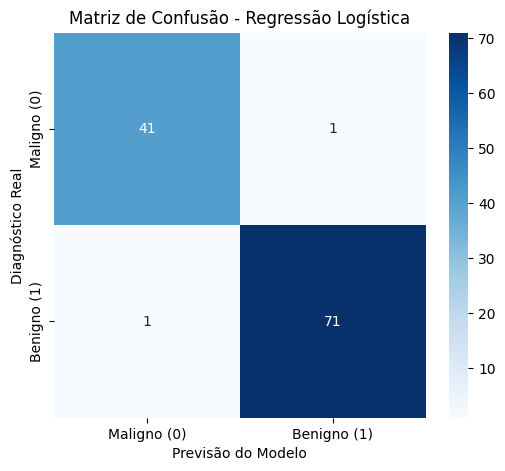

✅ Arquivos 'modelo_breast_cancer.pkl' e 'scaler.pkl' salvos com sucesso no ambiente!


In [6]:
# Passo 6: Matriz de Confusão e Salvamento do Modelo (.pkl)
import joblib
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Gerando a Matriz de Confusão do melhor modelo (Regressão Logística)
y_pred = modelo_sucesso.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

# 2. Plotando o gráfico da Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Maligno (0)', 'Benigno (1)'],
            yticklabels=['Maligno (0)', 'Benigno (1)'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Diagnóstico Real')
plt.show()

# 3. Salvando o Modelo e o Scaler em arquivos .pkl
joblib.dump(modelo_sucesso, 'modelo_breast_cancer.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Arquivos 'modelo_breast_cancer.pkl' e 'scaler.pkl' salvos com sucesso no ambiente!")